# Собираем базовую RAG-систему

In [5]:
!pip install -q PyMuPDF==1.26.1

### 1. Обработка документов/текста

Используем первые шаги по обработке документов из занятия «Анализ и подготовка документов». Там мы рассматривали, как с помощью разных библиотек в Python можно обрабатывать PDF-документы, извлекать необходимую информацию и дальше работать с ней, как с текстом.

**Компоненты:**  
* PDF-документ на выбор.
* Модель для создания эмбеддингов на выбор.

**Шаги:**  
1. Импортировать PDF-документ.
2. Обработать текст для эмбеддингов (например, разбить на предложения/фрагменты). Текст разбивается на логические части (чанки) для эффективного моделирования.
3. Создать эмбеддинги для текстовых фрагментов с помощью выбранной модели. Используются современные модели (например, BERT, Sentence-BERT, GPT-Embeddings).  
4. Сохранить эмбеддинги в файл для последующего использования  
*(эмбеддинги будут храниться годами или до потери жесткого диска)*. Рекомендуемые форматы хранения: `.npy`, `.h5`, `.pt` (PyTorch).

## Импорт PDF-документов  
Этот подход работает с разными типами документов. Мы начнем с PDF из-за популярности формата.  

**Важно:** метод также поддерживает:  
- Текстовые файлы (.txt)  
- Цепочки писем (email threads)  
- Техническую документацию  
- Статьи и научные работы  

**Пример использования:**  
Представим, что мы студенты-диетологи Гавайского университета, изучающие открытый учебник [*«Питание человека: издание 2020 года»*](https://pressbooks.oer.hawaii.edu/humannutrition2/).    

In [1]:
import os

pdf_path = "Глубокое обучение.pdf"

assert os.path.exists(pdf_path), f"Файл {pdf_path} не найден"
print(f"Файл {pdf_path} найден.")

Файл Глубокое обучение.pdf найден.


**PDF успешно загружен!**

Мы можем преобразовать страницы PDF в текстовый формат, выполнив шаги:  
1. Определить путь к PDF-файлу.  
2. Открыть и прочитать его с помощью библиотеки **PyMuPDF** (используется через `import fitz`).

**Процесс обработки:**  
- Создайте **вспомогательную функцию** для предобработки текста во время чтения.  
- Обратите внимание: текст может считываться неоднородно (например, разное форматирование таблиц/текста), что требует адаптивной обработки.  

**Структура данных:**  
Каждая страница сохраняется в виде словаря, который затем добавляется в список для удобства дальнейшего использования.  

Пример структуры словаря:  
```python
{
    "page_number": 1,
    "text": "Содержание страницы...",
    "metadata": {"автор": "Иван Петров"}
}
```

In [2]:
# Требуется установка PyMuPDF: !pip install PyMuPDF (репозиторий: https://github.com/pymupdf/pymupdf)
# Примечание: библиотека использует лицензию AGPL-3.0 (учитывайте при коммерческом использовании кода)
import fitz  # pymupdf (выбрана вместо pypdf для нашего кейса)
from tqdm.auto import tqdm  # индикатор выполнения, установка: !pip install tqdm


def text_formatter(text: str) -> str:
    """Выполняет базовое форматирование текста."""
    cleaned_text = text.replace("\n", " ").strip()  # примечание: обработка может отличаться для разных документов
    return cleaned_text  # сюда можно добавить другие функции форматирования


# Чтение PDF и извлечение текста/страниц
# Примечание: работает только с текстом (изображения/графики игнорируются)
def open_and_read_pdf(pdf_path: str) -> list[dict]:
    """
    Открывает PDF-файл и извлекает текст со страниц со сбором статистики.

    Параметры:
        pdf_path (str): Путь к PDF-документу

    Возвращает:
        list[dict]: Список словарей с данными для каждой страницы:
            - page_number: номер страницы (с коррекцией)
            - page_char_count: количество символов
            - page_word_count: количество слов
            - page_sentence_count_raw: примерное количество предложений
            - page_token_count: оценка токенов (1 токен ≈ 4 символа)
            - text: обработанный текст страницы
    """
    doc = fitz.open(pdf_path)  # открываем документ
    pages_and_texts = []
    for page_number, page in tqdm(enumerate(doc)):  # итерируем страницы с прогресс-баром
        text = page.get_text()  # получаем текст в UTF-8
        text = text_formatter(text)
        pages_and_texts.append({
            "page_number": page_number - 22,  # коррекция нумерации (PDF начинается с 22 стр.)
            "page_char_count": len(text),
            "page_word_count": len(text.split(" ")),
            "page_sentence_count_raw": len(text.split(". ")),
            "page_token_count": len(text) // 4,  # расчет токенов: https://help.openai.com/en/articles/4936856-what-are-tokens-and-how-to-count-them
            "text": text
        })
    return pages_and_texts


pages_and_texts = open_and_read_pdf(pdf_path=pdf_path)
pages_and_texts[:2]  # просмотр первых двух элементов

0it [00:00, ?it/s]

[{'page_number': -22,
  'page_char_count': 2582,
  'page_word_count': 331,
  'page_sentence_count_raw': 20,
  'page_token_count': 645,
  'text': 'Интернет\ue02dмагазин: www.dmkpress.com Книга – почтой: e\ue02dmail: orders@alians-kniga.ru Оптовая продажа:  «Альянс\ue02dкнига» Тел./факс: (499) 782\ue02d3889 e\ue02dmail: books@alians-kniga.ru www.дмк.рф Глубокое обучение — это вид машинного обучения, наделяющий компьютеры  способностью учиться на опыте. Книга содержит математические и концептуальные  основы линейной алгебры, теории вероятностей и теории информации, численных  расчетов и машинного обучения в том объеме, который необходим для понимания  материала. Описываются приемы глубокого обучения, применяемые на практике, в том  числе глубокие сети прямого распространения, регуляризация, алгоритмы оптимизации,  сверточные сети, моделирование последовательностей и др. Рассматриваются такие  приложения, как обработка естественных языков, распознавание речи, компьютерное  зрение, онлайнов

Теперь возьмем случайную выборку страниц.

In [3]:
import random

random.sample(pages_and_texts, k=3)

[{'page_number': 181,
  'page_char_count': 2133,
  'page_word_count': 289,
  'page_sentence_count_raw': 18,
  'page_token_count': 533,
  'text': 'Штрафы по норме параметров\u2003 \uf076\u2003 203 w~ w* w1 w2 Рис. 7.1\u2002 \uf076\u2002 Иллюстрация влияния регуляризации по норме L2 (снижения  весов) на значение оптимального вектора w. Сплошными эллипсами пред- ставлены линии равных значений нерегуляризированной целевой функции,  а\xa0пунктирными\xa0– линии равных значений L2-регуляризатора. В\xa0точке w~ эти  конкурирующие цели достигают равновесия. По первому измерению соб- ственное значение гессиана\u2002 J мало. Целевая функция слабо растет при  удалении от w* по горизонтали. Поскольку целевая функция не выказывает  сильного предпочтения этому направлению, регуляризатор дает для него  значительный эффект. Регуляризатор подтягивает w1 ближе к\xa0нулю. По вто- рому направлению целевая функция очень чувствительна к\xa0удалению от w*.  Соответствующее собственное значение велико, что ука

## Получение статистики по текстам

Проведем предварительный анализ данных (EDA), чтобы понять объем текста, количество символов, слов и так далее. Это поможет определить оптимальный способ их разбиения.

Многие модели для создания эмбеддингов имеют ограничения на длину входных текстов. Например, модель [`all-mpnet-base-v2`](https://huggingface.co/sentence-transformers/all-mpnet-base-v2) из библиотеки [`sentence-transformers`](https://www.sbert.net/docs/pretrained_models.html) принимает максимум **384 токена**.
  
Это означает, что модель обучена работать с текстами длиной до 384 токенов (где: 1 токен ≈ 4 символа ≈ 0.75 слова).

Тексты длиннее 384 токенов будут автоматически обрезаться при обработке этой моделью, что может привести к потере информации.

Более подробно мы обсудим это в разделе про создание эмбеддингов.

А сейчас преобразуем наш список словарей в `DataFrame` и проанализируем его.

In [4]:
import pandas as pd

df = pd.DataFrame(pages_and_texts)
df.head()

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,text
0,-22,2582,331,20,645,Интернетмагазин: www.dmkpress.com Книга – поч...
1,-21,61,8,1,15,"Ян Гудфеллоу, Иошуа Бенджио, Аарон Курвилль Гл..."
2,-20,115,15,1,28,"Ian Goodfellow, Yoshua Bengio, Aaron Courville..."
3,-19,112,15,1,28,"Ян Гудфеллоу, Иошуа Бенджио, Аарон Курвилль Гл..."
4,-18,1916,254,18,479,"УДК 004.85 ББК 32.971.3 Г93 Гудфеллоу Я., Бенд..."


In [5]:
# Статистика
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count
count,653.00,653.00,653.00,653.00,653.00
mean,304.00,2759.54,364.75,26.27,689.49
std,188.65,728.07,93.57,21.45,182.02
min,-22.00,61.00,8.00,1.00,15.00
25%,141.00,2324.00,307.00,17.00,581.00
50%,304.00,2850.00,375.00,22.00,712.00
75%,467.00,3321.00,440.00,26.00,830.00
max,630.00,5307.00,528.00,120.00,1326.00


По этим данным среднее количество токенов на страницу составляет 287.

Это означает, что для нашего случая можно использовать модель `all-mpnet-base-v2` (с максимальной длиной входа 384 токена) для создания эмбеддингов целых страниц без обрезки.

## Дальнейшая обработка текста (разбиение страниц на предложения)  
Идеальный способ предобработки текста перед созданием эмбеддингов все еще является предметом исследований.  

**Простой рабочий метод:** разбивать текст на группы предложений (чанки) по 5, 7, 10 или более предложений. Эти значения можно настраивать под ваши задачи.  



### Общий рабочий процесс:  
1. Загрузить текст.  
2. Разделить на чанки.  
3. Создать эмбеддинги для чанков.  
4. Использовать эмбеддинги.



### Методы разбиения на предложения:  
- **Базовый:** Разделение по `. ` (например, `text.split(". ")`, как делали ранее).
- **Продвинутый:** Использование NLP-библиотек (spaCy, nltk).  



### Зачем разбивать на предложения?  
- Упрощение обработки (особенно для плотных текстов).  
- Возможность точно определить, **какие предложения** повлияли на результат в RAG-пайплайне.



**Рекомендация:** используйте spaCy для разбиения, так как это надежнее, чем простое разделение по `. `.

In [6]:
# Импорт английского языка для spaCy (инструкции по установке: https://spacy.io/usage)
from spacy.lang.en import English

# Создаем объект NLP для английского языка
nlp = English()

# Добавляем компонент sentencizer в пайплайн (документация: https://spacy.io/api/sentencizer/)
nlp.add_pipe("sentencizer")

# Создаем пример документа для тестирования
doc = nlp("This is a sentence. This another sentence.")
assert len(list(doc.sents)) == 2  # Проверяем, что текст разбит на 2 предложения

# Получаем и выводим список предложений документа
list(doc.sents)

[This is a sentence., This another sentence.]

Необязательно использовать spaCy, однако это библиотека с открытым исходным кодом, специально созданная для масштабной обработки NLP-задач, таких как наша.  

Давайте применим наш небольшой **пайплайн для разбиения на предложения** к текстовым страницам.

In [7]:
for item in tqdm(pages_and_texts):
    item["sentences"] = list(nlp(item["text"]).sents)

    # Проверяем что все предложения это строки
    item["sentences"] = [str(sentence) for sentence in item["sentences"]]

    # Считаем предложения
    item["page_sentence_count_spacy"] = len(item["sentences"])

  0%|          | 0/653 [00:00<?, ?it/s]

In [8]:
# Проверим
random.sample(pages_and_texts, k=1)

[{'page_number': 39,
  'page_char_count': 2302,
  'page_word_count': 282,
  'page_sentence_count_raw': 16,
  'page_token_count': 575,
  'text': 'Глава 3 Теория вероятностей  и\xa0теория информации В этой главе мы изложим основы теории вероятностей и\xa0теории информации. Теория вероятностей\xa0– это раздел математики, в\xa0котором рассматриваются недос\xad товерные утверждения. Она дает средства количественно описать недостоверность,  а\xa0 также аксиомы для вывода новых недостоверных утверждений. В\xa0 применении  к\xa0искусственному интеллекту теория вероятностей используется в\xa0основном двумя  способами. Во-первых, ее правила говорят нам, как должна рассуждать система ИИ,  поэтому мы проектируем алгоритмы, которые вычисляют или аппроксимируют раз- личные выражения, полученные на основе теории вероятностей. Во-вторых, теорию  вероятностей и\xa0математическую статистику можно применить для теоретического  анализа поведения предлагаемых систем ИИ. Теория вероятностей лежит в\xa0 осно

Отлично! Теперь преобразуем наш список словарей в DataFrame и получим статистические данные.

In [9]:
import pandas as pd


df = pd.DataFrame(pages_and_texts)

Похоже, что для нашего набора текстов грубый подсчет предложений (например, разделение по `". "`) довольно близок к тому, что показал spaCy.

Теперь, когда у нас есть текст, разделенный на предложения, давайте сгруппируем эти предложения.

## Группировка предложений

Давайте сделаем шаг к разбиению нашего списка предложений или текста на мелкие части.

Как вы могли догадаться, этот процесс называется **чанкинг** (группировка).

### Почему мы это делаем?

1. Легче управлять частями текста похожего размера.
2. Не перегружать емкость моделей для создания эмбеддингов токенами (например, если модель для создания эмбеддингов имеет емкость 384 токена, может произойти потеря информации, если вы попытаетесь создать эмбеддинг для последовательности из 400+ токенов).
3. Наше окно контекста LLM (количество токенов, которое LLM может обработать) может быть ограничено и требует вычислительной мощности, поэтому мы хотим убедиться, что используем его максимально эффективно.

**На заметку**: существует множество способов для создания частей текста.

Пока мы будем держаться простого подхода и разобьем наши страницы с предложениями на группы по 10 (это число произвольное и может быть изменено, я выбрал его потому, что оно хорошо соответствует емкости нашей модели для создания эмбеддингов в 384 токена).

В среднем каждая из наших страниц содержит 10 предложений.

И в среднем 287 токенов на страницу.

Таким образом, наши группы по 10 предложений также будут длиной около 287 токенов.

Это дает нам достаточно места для создания эмбеддингов текста с помощью нашей модели `all-mpnet-base-v2` (емкость модели — 384 токена).

Чтобы разделить наши группы предложений на части по 10 или меньше, давайте создадим функцию, которая принимает список на вход и рекурсивно разбивает его на подсписки указанного размера.

In [10]:
# Определим размер разделения для преобразования групп предложений в чанки
num_sentence_chunk_size = 10

# Создадим функцию, которая рекурсивно разбивает список на нужные размеры
def split_list(input_list: list,
               slice_size: int) -> list[list[str]]:
    """
    Разбивает input_list на подсписки размером slice_size (или максимально близко к этому).

    Например, список из 17 предложений будет разбит на два списка [[10], [7]]
    """
    return [input_list[i:i + slice_size] for i in range(0, len(input_list), slice_size)]

# Перебираем страницы и тексты и разбиваем предложения на чанки
for item in tqdm(pages_and_texts):
    item["sentence_chunks"] = split_list(input_list=item["sentences"],
                                         slice_size=num_sentence_chunk_size)
    item["num_chunks"] = len(item["sentence_chunks"])

  0%|          | 0/653 [00:00<?, ?it/s]

In [11]:
# Возьмем пример из группы (примечание: многие примеры имеют только 1 чанк, так как у них <=10 предложений всего)
random.sample(pages_and_texts, k=1)

[{'page_number': 553,
  'page_char_count': 3350,
  'page_word_count': 432,
  'page_sentence_count_raw': 22,
  'page_token_count': 837,
  'text': 'Обратное распространение через\xa0случайные\xa0операции\u2003 \uf076\u2003 575 ОМБ не так хорошо обучаются с\xa0учителем, как МСП, по крайней мере с\xa0применени- ем существующих технологий. В большинстве практически используемых машин Больцмана функция энергии  включает только взаимодействия второго порядка, т.\xa0е. представляет собой суммы  большого числа членов, каждый из которых является произведением всего двух  случайных величин, например viWi,\u2009j\u2009hj. Можно обучить и\xa0машины Больцмана более  высокого порядка (Sejnowski, 1987), для которых члены функции энергии являются  произведениями многих величин. Трехсторонние взаимодействия между скрытым  блоком и\xa0 двумя разными изображениями могут моделировать пространственное  преобразование между текущим и\xa0следующим кадрами видео (Memisevic and Hinton,  2007, 2010). Умножение н

In [12]:
# Создадим DataFrame для получения статистики
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy,num_chunks
count,653.00,653.00,653.00,653.00,653.00,653.00,653.00
mean,304.00,2759.54,364.75,26.27,689.49,25.45,2.99
std,188.65,728.07,93.57,21.45,182.02,16.37,1.65
min,-22.00,61.00,8.00,1.00,15.00,1.00,1.00
25%,141.00,2324.00,307.00,17.00,581.00,17.00,2.00
50%,304.00,2850.00,375.00,22.00,712.00,23.00,3.00
75%,467.00,3321.00,440.00,26.00,830.00,27.00,3.00
max,630.00,5307.00,528.00,120.00,1326.00,96.00,10.00


Обратите внимание, что среднее количество чанков составляет около 1.5. Это ожидаемо, так как многие из наших страниц содержат в среднем только 10 предложений.

## Разделение каждого чанка на отдельный элемент

Мы хотим преобразовать каждый чанк предложений в его собственное числовое представление.

Чтобы сохранить порядок, давайте создадим новый список словарей, где каждый словарь будет содержать один чанк предложений вместе с соответствующей информацией (такой как номер страницы), а также статистику о каждом чанке.

In [13]:
import re

# Разделяем каждый чанк на отдельный элемент
pages_and_chunks = []
for item in tqdm(pages_and_texts):
    for sentence_chunk in item["sentence_chunks"]:
        chunk_dict = {}
        chunk_dict["page_number"] = item["page_number"]

        # Объединяем предложения в структуру абзаца, т.е. чанк (таким образом, они являются одной строкой)
        joined_sentence_chunk = "".join(sentence_chunk).replace("  ", " ").strip()
        joined_sentence_chunk = re.sub(r'\.([A-Z])', r'. \1', joined_sentence_chunk) # ".A" -> ". A" для любой комбинации точки и заглавной буквы
        chunk_dict["sentence_chunk"] = joined_sentence_chunk

        # Получаем статистику о чанке
        chunk_dict["chunk_char_count"] = len(joined_sentence_chunk)
        chunk_dict["chunk_word_count"] = len([word for word in joined_sentence_chunk.split(" ")])
        chunk_dict["chunk_token_count"] = len(joined_sentence_chunk) / 4 # 1 token = ~4 characters

        pages_and_chunks.append(chunk_dict)

# Сколько у нас чанков?
len(pages_and_chunks)

  0%|          | 0/653 [00:00<?, ?it/s]

1955

In [14]:
# Посмотрим на случайный образец
random.sample(pages_and_chunks, k=1)

[{'page_number': 627,
  'sentence_chunk': 'Стохастическая максимизация правдоподобия Снижение весов, 113, 158, 201, 363 Сновидения, 512, 547 СНС.См.Сверточная нейронная сеть Собственная информация, 77 Собственное значение, 53 Собственный вектор, 52 Совместное распределение вероятности, 64 Сопоставительное расхождение, 250, 512, 563 Сопоставление моментов, 589 Сопоставление рейтингов, 430, 519 Состоятельность, 122, 430 Состоятельность, 122 Состязательное обучение, 232, 236, 446 Состязательный пример, 232 Спектральное разложение, 52 Спектральный радиус, 341 Сравнение с образцом, 131 Среднее поле, 536, 562 Среднеквадратическая ошибка, 104',
  'chunk_char_count': 600,
  'chunk_word_count': 70,
  'chunk_token_count': 150.0}]

Отлично!

Теперь мы разбили весь наш учебник на чанки по 10 предложений или меньше, а также сохранили номер страницы, из которой они взяты.

Это означает, что мы можем ссылаться на чанк текста и знать его источник.

Давайте получим статистику по нашим чанкам.

In [15]:
# Получаем статистику о наших чанках
df = pd.DataFrame(pages_and_chunks)
df.describe().round(2)

,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,1955.00,1955.00,1955.00,1955.00
mean,339.21,909.30,110.12,227.32
std,201.94,478.75,58.90,119.69
min,-22.00,4.00,1.00,1.00
25%,162.50,451.00,58.00,112.75
50%,346.00,970.00,114.00,242.50
75%,538.00,1258.00,153.00,314.50
max,630.00,3310.00,451.00,827.50


Хм, похоже, что некоторые из наших чанков имеют довольно низкое количество токенов.

Давайте проверим примеры с менее чем 30 токенами (примерно длина предложения) и посмотрим, стоит ли их сохранять.

In [16]:
# Покажем случайные чанки с длиной менее 30 токенов
min_token_length = 30
for row in df[df["chunk_token_count"] <= min_token_length].sample(5).iterrows():
    print(f'Chunk token count: {row[1]["chunk_token_count"]} | Text: {row[1]["sentence_chunk"]}')

Chunk token count: 24.5 | Text: В машинном обучении допускаются многообразия, размерность которых различна в разных точках.Так ча-
Chunk token count: 25.5 | Text: От начальной точки мо- жет зависеть, сойдется ли вообще алгоритм, причем некоторые начальные точки так
Chunk token count: 29.0 | Text: Послойное предобучение...........................................................................................560
Chunk token count: 16.0 | Text: Все готово к  построению и  анализу полноценных систем обучения.
Chunk token count: 10.25 | Text: Neural Turing machines.arX- iv:1410.5401.


Похоже, что многие из них являются заголовками и подписями разных страниц.

И они не содержат много полезной информации.

Давайте отфильтруем наш DataFrame/список словарей, чтобы включить только чанки с длиной более 30 токенов.

In [17]:
pages_and_chunks_over_min_token_len = df[df["chunk_token_count"] > min_token_length].to_dict(orient="records")
pages_and_chunks_over_min_token_len[:2]

[{'page_number': -22,
  'sentence_chunk': 'Интернет\ue02dмагазин: www.dmkpress.com Книга – почтой: e\ue02dmail: orders@alians-kniga.ru Оптовая продажа: «Альянс\ue02dкнига» Тел./факс: (499) 782\ue02d3889 e\ue02dmail: books@alians-kniga.ru www.дмк.рф Глубокое обучение — это вид машинного обучения, наделяющий компьютеры способностью учиться на опыте.Книга содержит математические и концептуальные основы линейной алгебры, теории вероятностей и теории информации, численных расчетов и машинного обучения в том объеме, который необходим для понимания материала.Описываются приемы глубокого обучения, применяемые на практике, в том числе глубокие сети прямого распространения, регуляризация, алгоритмы оптимизации, сверточные сети, моделирование последовательностей и др.Рассматриваются такие приложения, как обработка естественных языков, распознавание речи, компьютерное зрение, онлайновые рекомендательные системы, биоинформатика и видеоигры. Наконец, описываются перспективные направления исследовани

Меньшие чанки отфильтрованы!

Пришло время создать эмбеддинги для наших чанков текста!

**Векторное представление текстовых фрагментов**  

Люди понимают текст, а машины лучше работают с числами.  

**Эмбеддинг** (embedding) — это общая концепция, но одно из моих любимых простых определений: *«полезное числовое представление»*. Главная особенность современных эмбеддингов в том, что они являются **обучаемыми представлениями**. Это означает, что вместо прямой замены слов/токенов/символов на числа (например, `{"a": 0, "b": 1, "c": 3...}`) числовое представление токенов формируется в процессе обучения на больших текстовых корпусах, где модель анализирует взаимосвязи между ними. В идеале, эмбеддинги текста должны отражать смысловую близость: похожие по смыслу фрагменты будут иметь похожие числовые представления.  

> **Примечание:** Большинство современных NLP-моделей работают с «токенами», которые могут представлять собой комбинации символов или частей слов, а не целые слова. Например, строка `"hello world!"` с использованием байт-парного кодирования (BPE через библиотеку OpenAI [`tiktoken`](https://github.com/openai/tiktoken)) преобразуется в токены `{15339: b'hello', 1917: b' world', 0: b'!'}`. У Google есть собственная библиотека токенизации — [SentencePiece](https://github.com/google/sentencepiece).  

**Наша цель** — преобразовать каждый текстовый фрагмент в числовое представление (вектор эмбеддинга, где вектор — это упорядоченная последовательность чисел).  

После преобразования текста в векторы люди не смогут их интерпретировать, но это и не нужно. Эмбеддинги предназначены для машин. С их помощью компьютеры находят паттерны в данных, а мы можем использовать сопоставление с исходным текстом для анализа.  

**Перейдем к практике.** Возьмем модель для создания эмбеддингов и посмотрим, как это работает. Для этого используем библиотеку [`sentence-transformers`](https://www.sbert.net/docs/installation.html), которая содержит множество предобученных моделей. В частности, возьмем модель `all-mpnet-base-v2` (её описание можно найти в [Hugging Face model card](https://huggingface.co/sentence-transformers/all-mpnet-base-v2#intended-uses)).

In [18]:
# Требуется установка: !pip install sentence-transformers
from sentence_transformers import SentenceTransformer, util
embedding_model = SentenceTransformer(model_name_or_path="all-mpnet-base-v2",
                                      device="cuda")

# Создаем список предложений для преобразования в числа
sentences = [
    "The Sentences Transformers library provides an easy and open-source way to create embeddings.",
    "Sentences can be embedded one by one or as a list of strings.",
    "Embeddings are one of the most powerful concepts in machine learning!",
    "Learn to use embeddings well and you'll be well on your way to being an AI engineer."
]

# Предложения кодируются/преобразуются в эмбеддинги через model.encode()
embeddings = embedding_model.encode(sentences)
embeddings_dict = dict(zip(sentences, embeddings))

# Просматриваем эмбеддинги
for sentence, embedding in embeddings_dict.items():
    print("Sentence:", sentence)
    print("Embedding:", embedding[:15])
    print("")

Sentence: The Sentences Transformers library provides an easy and open-source way to create embeddings.
Embedding: [-0.02079814  0.0303165  -0.0201218   0.06864841 -0.02552551 -0.00847691
 -0.00020709 -0.06323772  0.02816065 -0.03333531  0.03026346  0.05307209
 -0.05035264  0.02622882  0.0333314 ]

Sentence: Sentences can be embedded one by one or as a list of strings.
Embedding: [ 0.04317179 -0.05387009 -0.03780447  0.04272355 -0.02354094  0.03448613
  0.0289587   0.00192815  0.0241733  -0.03170121  0.07328562  0.01255898
  0.03646208 -0.02052521  0.02819738]

Sentence: Embeddings are one of the most powerful concepts in machine learning!
Embedding: [-0.02986113 -0.0137522  -0.04754019  0.02721268  0.03400549  0.03164659
  0.04269637  0.00329794  0.04357173  0.02538371  0.03025293  0.0321131
 -0.03999129  0.01287608  0.06702201]

Sentence: Learn to use embeddings well and you'll be well on your way to being an AI engineer.
Embedding: [-0.02207308  0.02089505 -0.06030053  0.00843944  0

Ого! Так много чисел. Давайте возьмем всего одно предложение?  

In [19]:
single_sentence = "Yo! How cool are embeddings?"
single_embedding = embedding_model.encode(single_sentence)
print(f"Sentence: {single_sentence}")
print(f"Embedding:\n{single_embedding}")
print(f"Embedding size: {single_embedding.shape}")

Sentence: Yo! How cool are embeddings?
Embedding:
[-1.97447482e-02 -4.51086182e-03 -4.98482399e-03  6.55444786e-02
 -9.87671129e-03  2.72835419e-02  3.66425849e-02 -3.30220140e-03
  8.50079395e-03  8.24950915e-03 -2.28497162e-02  4.02430333e-02
 -5.75200208e-02  6.33692592e-02  4.43207584e-02 -4.49506864e-02
  1.25284418e-02 -2.52012033e-02 -3.55292298e-02  1.29559161e-02
  8.67023412e-03 -1.92917623e-02  3.55634838e-03  1.89506039e-02
 -1.47128487e-02 -9.39844828e-03  7.64170708e-03  9.62190423e-03
 -5.98929077e-03 -3.90169397e-02 -5.47824763e-02 -5.67457778e-03
  1.11645311e-02  4.08067293e-02  1.76319088e-06  9.15297680e-03
 -8.77263211e-03  2.39382759e-02 -2.32784618e-02  8.04999247e-02
  3.19176652e-02  5.12596872e-03 -1.47708412e-02 -1.62524544e-02
 -6.03213347e-02 -4.35689352e-02  4.51211184e-02 -1.79053731e-02
  2.63367128e-02 -3.47866789e-02 -8.89173709e-03 -5.47675006e-02
 -1.24372886e-02 -2.38606595e-02  8.33496451e-02  5.71242422e-02
  1.13328528e-02 -1.49595151e-02  9.2037

Отлично! Теперь у нас есть способ численно представить каждый из фрагментов.  

Размер эмбеддинга — `(768,)`, что означает вектор из 768 чисел, представляющих наш текст в многомерном пространстве (слишком много для человеческого восприятия, но машины обожают многомерные пространства).  

> **Примечание:** Независимо от длины входного текста, модель `all-mpnet-base-v2` преобразует его в эмбеддинг фиксированного размера `(768,)`. Если предложение содержит 1 токен или 1000 токенов, оно будет обрезано/дополнено нулями до длины 384 токена, а затем преобразовано в вектор размером `(768,)`. Другие модели эмбеддингов могут иметь иные размеры входов/выходов.  

Что если добавить поле для эмбеддинга к каждому фрагменту?  

Мы можем выполнять батч операции, объединив целевые текстовые фрагменты в единый список и передав его модели эмбеддингов.  

In [20]:
# Turn text chunks into a single list
text_chunks = [item["sentence_chunk"] for item in pages_and_chunks_over_min_token_len]

In [23]:
embs = embedding_model.encode(text_chunks, show_progress_bar=True)

for item, emb in tqdm(zip(pages_and_chunks_over_min_token_len, embs)):
    item["embedding"] = emb

Batches:   0%|          | 0/60 [00:00<?, ?it/s]

0it [00:00, ?it/s]

### Сохранение эмбеддингов в файл  

Поскольку создание эмбеддингов может занимать много времени (для нашего примера это не так критично, но для больших наборов данных это важно), преобразуем список словарей `pages_and_chunks_over_min_token_len` в DataFrame и сохраним его.  

In [24]:
# Save embeddings to file
text_chunks_and_embeddings_df = pd.DataFrame(pages_and_chunks_over_min_token_len)
embeddings_df_save_path = "text_chunks_and_embeddings_df.csv"
text_chunks_and_embeddings_df.to_csv(embeddings_df_save_path, index=False)

И мы можем убедиться, что импорт выполняется корректно, загрузив данные.  

In [25]:
# Import saved file and view
text_chunks_and_embedding_df_load = pd.read_csv(embeddings_df_save_path)
text_chunks_and_embedding_df_load.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,-22,Интернетмагазин: www.dmkpress.com Книга – поч...,1826,203,456.50,[ 5.73022030e-02 1.31870825e-02 9.71500203e-...
1,-22,"Иошуа Бенджио (Yoshua Bengio), профессор факул...",707,80,176.75,[ 4.74029779e-03 2.20878124e-02 -2.18484905e-...
2,-18,"УДК 004.85 ББК 32.971.3 Г93 Гудфеллоу Я., Бенд...",343,47,85.75,[ 5.03928289e-02 -1.62824523e-02 2.00766437e-...
3,-18,Книга содержит математические и концептуальные...,1388,160,347.00,[ 1.30547136e-02 1.38159422e-02 6.35933736e-...
4,-18,ISBN 978-1-491-93799-0 (анг.)\t © 2017 Massach...,155,19,38.75,[ 2.21460685e-03 -8.83318856e-02 -4.12737802e-...


### Разделение текста на фрагменты и создание эмбеддингов: вопросы  

> **Какую модель эмбеддингов выбрать?**  
Это зависит от множества факторов. Лучший совет: экспериментируйте!  
Если модель должна работать локально, убедитесь, что её можно запустить на вашем оборудовании.  
Для сравнения моделей используйте [Hugging Face MTEB Leaderboard](https://huggingface.co/spaces/mteb/leaderboard) — рейтинг моделей по различным задачам.  

> **Какие ещё способы разделения текста существуют?**  
Вариантов много. Мы использовали простую группировку по предложениям.  
Подробнее:  
- [Гайд Pinecone по методам чанкинга](https://www.pinecone.io/learn/chunking-strategies/) (включая Markdown и LaTeX).  
- [LangChain](https://python.langchain.com/docs/modules/data_connection/document_transformers/) — библиотека с встроенными инструментами для разделения текста.  

> **На что обратить внимание при создании эмбеддингов?**  
Наша модель преобразует тексты длиной до **384 токенов** в векторы размером **768**.  
Общие принципы:  
- **Размер вектора**: Чем больше, тем больше информации кодируется (но компактные модели иногда эффективнее).  
- **Размер модели**: Крупные модели могут давать лучшие эмбеддинги, но требуют больше ресурсов.  
- **Открытость**: Открытые модели работают локально, закрытые требуют API-вызовов.  

**Ключевые аспекты:**  
1. Длина входных данных — выбирайте модели с подходящей ёмкостью.  
2. Размер эмбеддинга — баланс между качеством и затратами на хранение/вычисления.  
3. Сложность модели — соотносите с доступными ресурсами.  

> **Где хранить эмбеддинги?**  
- Для небольших наборов (до ~100 000 примеров) подойдут `np.array` или `torch.tensor`.  
- Для продакшена с миллионами эмбеддингов используйте [векторные базы данных](https://en.wikipedia.org/wiki/Vector_database).  

### Расширение функционала: создание эмбеддингов для документов  
Основное улучшение — автоматизация процесса:  
- Объедините все этапы в скрипт (документ → файл с эмбеддингами).  
- **Главная задача**: предобработка текста. Чем «чище» данные, тем лучше результат.  
- Пример: удаление шума, нормализация, фильтрация нерелевантных фрагментов.  

## 2. RAG — Поиск и генерация ответов  

Мы уже кратко обсуждали RAG в начале, но давайте повторим.  

**RAG (Retrieval Augmented Generation)** — это подход, который можно описать как «по заданному запросу найти релевантные ресурсы и сгенерировать ответ на их основе».  

### Этапы RAG:  
1. **Поиск (Retrieval)** — Получение релевантных ресурсов для запроса.  
   - *Пример*: Если запрос — «Что такое макронутриенты?», в результатах поиска должна быть информация о белках, углеводах и жирах (а не о тракторах для фермерства, хотя это тоже интересно).  

2. **Расширение (Augmentation)** — Использование найденных ресурсов для улучшения генерации.  
   - LLM (большие языковые модели) способны генерировать текст, который *выглядит* правдоподобно, но может содержать ошибки или «галлюцинации» (вымышленные факты).  
   - На этапе расширения в промпт добавляется найденная информация, и LLM использует её как основу для генерации.  

3. **Генерация (Generation)** — Создание ответа, обогащённого найденными ресурсами.  
   - Это не только повышает точность ответа, но и даёт ссылки на источники, которые можно проверить.  

### Зачем нужен RAG?  
- **Повышение точности**: Ответы LLM становятся более фактологически корректными благодаря внешним данным.  
- **Ссылки на источники**: Пользователь видит, на какой информации основан ответ.  

### Примеры применения:  
- **Поддержка клиентов**: Используйте RAG для генерации ответов на вопросы с ссылками на документацию из тысяч файлов.  
- **Страховые компании**: Анализируйте письма о страховых случаях и отвечайте на запросы, указывая источники.  

**Аналогия**: LLM — это «калькулятор для слов».  
- Чем лучше входные данные (релевантные ресурсы), тем полезнее результат.  
- Всё начинается с эффективного поиска.  

### Семантический поиск  

Семантический (векторный) поиск — это поиск по *смыслу*, а не по ключевым словам.  
Если это звучит абстрактно, то на практике всё просто.  

**Чем он отличается от обычного поиска?**  
- **Ключевой поиск**: Ищет точное совпадение строк (например, "яблоко" → "яблоко").  
- **Семантический поиск**: Ищет тексты, соответствующие *смыслу* запроса, даже без прямого совпадения слов.  

> **Пример**: Запрос "функции макронутриентов" может вернуть абзац:  
>  
> *«Существует три класса макронутриентов: углеводы, липиды и белки. Они метаболизируются в клеточную энергию. Энергия макронутриентов поступает из их химических связей. Эта энергия преобразуется в клеточную, которая используется для выполнения работы, обеспечивающей базовые функции организма»*.  
>  
> Хотя в тексте нет точной фразы "функции макронутриентов", он релевантен по смыслу.  

**Как это работает?**  
1. **Подготовка данных**:  
   - Импортируем ранее созданные эмбеддинги (файл `embeddings.pkl`).  
   - Преобразуем их в тензор (например, через `torch.tensor()`).  
2. **Поиск**:  
   - Преобразуем запрос в эмбеддинг.  
   - Сравниваем его с эмбеддингами текстов (например, через косинусное сходство).  
   - Возвращаем наиболее близкие по смыслу фрагменты.  

**Где применяется?**  
- Поиск в личных документах, базах знаний, чат-ботах с контекстными ответами.  

In [26]:
import random

import torch
import numpy as np
import pandas as pd

# Определение устройства (GPU или CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Импорт текстовых фрагментов и эмбеддингов из CSV
text_chunks_and_embedding_df = pd.read_csv("text_chunks_and_embeddings_df.csv")

# Преобразование столбца 'embedding' обратно в np.array
# (при сохранении в CSV он преобразовался в строку)
text_chunks_and_embedding_df["embedding"] = text_chunks_and_embedding_df["embedding"].apply(
    lambda x: np.fromstring(x.strip("[]"), sep=" ")
)

# Преобразование DataFrame в список словарей
pages_and_chunks = text_chunks_and_embedding_df.to_dict(orient="records")

# Конвертация эмбеддингов в тензор PyTorch и отправка на устройство
# Примечание: массивы NumPy имеют тип float64, тензоры PyTorch по умолчанию — float32
embeddings = torch.tensor(
    np.array(text_chunks_and_embedding_df["embedding"].tolist()),
    dtype=torch.float32
).to(device)

# Проверка формы тензора
embeddings.shape

torch.Size([1898, 768])

In [27]:
text_chunks_and_embedding_df.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,-22,Интернетмагазин: www.dmkpress.com Книга – поч...,1826,203,456.50,"[0.057302203, 0.0131870825, 0.00971500203, -0...."
1,-22,"Иошуа Бенджио (Yoshua Bengio), профессор факул...",707,80,176.75,"[0.00474029779, 0.0220878124, -0.0218484905, -..."
2,-18,"УДК 004.85 ББК 32.971.3 Г93 Гудфеллоу Я., Бенд...",343,47,85.75,"[0.0503928289, -0.0162824523, 0.0200766437, -0..."
3,-18,Книга содержит математические и концептуальные...,1388,160,347.00,"[0.0130547136, 0.0138159422, 0.00635933736, -0..."
4,-18,ISBN 978-1-491-93799-0 (анг.)\t © 2017 Massach...,155,19,38.75,"[0.00221460685, -0.0883318856, -0.0412737802, ..."


In [28]:
embeddings[0]

tensor([ 5.7302e-02,  1.3187e-02,  9.7150e-03, -1.8877e-02, -1.9429e-02,
         2.5830e-02,  5.2257e-02,  2.1374e-02, -2.6570e-02, -3.7044e-03,
         4.6791e-02, -3.9378e-02, -2.8630e-03, -2.2316e-02,  4.9547e-02,
         8.3888e-03, -1.1372e-02, -6.0911e-03, -6.9320e-02,  1.5076e-03,
         3.5838e-03,  5.5475e-02, -6.9370e-02, -4.4635e-02,  3.7873e-02,
         2.1512e-03,  5.8721e-02, -2.4785e-02, -2.0472e-02,  2.2423e-03,
         1.2641e-02,  7.5274e-03, -3.9408e-02,  7.5643e-02,  2.3733e-06,
        -2.2492e-02, -4.8991e-03, -2.4365e-02,  7.2698e-03, -2.8378e-02,
         3.5265e-02, -1.8622e-02, -5.1656e-02, -7.5375e-02,  2.2343e-03,
        -5.0745e-02, -1.2743e-02,  8.0589e-02, -2.2366e-02,  5.5562e-02,
         8.0552e-03, -3.0696e-02,  4.9933e-02,  2.9974e-02, -4.2903e-02,
        -2.7243e-02, -2.1357e-02,  2.4616e-02, -3.9955e-02,  6.8916e-02,
         3.2935e-02,  2.3204e-02, -2.3516e-02, -2.3360e-02, -2.2396e-02,
         5.4610e-03,  3.8086e-02, -7.9932e-02,  1.5

Отлично! Теперь создадим ещё один экземпляр модели эмбеддингов.  
Это не обязательно, но позволит запускать блокнот, начиная с текущей ячейки.  

In [29]:
from sentence_transformers import util, SentenceTransformer

embedding_model = SentenceTransformer(model_name_or_path="all-mpnet-base-v2",
                                      device=device) # choose the device to load the model to

Модель эмбеддингов готова!  

**Время выполнить семантический поиск.**  

Предположим, вы изучаете макронутриенты и хотите найти в учебнике информацию по запросу **"функции макронутриентов"**.  

**Шаги для поиска:**  
1. **Задайте запрос** (например, `"функции макронутриентов"`).  
2. **Преобразуйте запрос в эмбеддинг** с помощью той же модели, что использовалась для фрагментов текста.  
3. **Рассчитайте сходство** между эмбеддингами текста и запроса:  
   - Используйте [скалярное произведение](https://pytorch.org/docs/stable/generated/torch.dot.html) или [косинусное сходство](https://ru.wikipedia.org/wiki/Косинусное_сходство).  
4. **Отсортируйте результаты** по убыванию сходства (чем выше оценка, тем релевантнее текст).  
5. **Проверьте найденные тексты.**  

In [30]:
# 1. Определение запроса
# Примечание: Запрос может быть любым. Но так как мы работаем с учебником по глубокому обучению, выберем тематические запросы.
query = "обратное распространение ошибки и градиентный спуск"
print(f"Запрос: {query}")

# 2. Преобразование запроса в числовое пространство (как текстовые примеры)
# Важно: Используйте ту же модель, что и для текстовых фрагментов.
query_embedding = embedding_model.encode(query, convert_to_tensor=True)

# 3. Расчет сходства через скалярное произведение (замерим время для интереса)
from time import perf_counter as timer

start_time = timer()
dot_scores = util.dot_score(a=query_embedding, b=embeddings)[0]
end_time = timer()

print(f"Время расчета сходства для {len(embeddings)} эмбеддингов: {end_time-start_time:.5f} сек.")

# 4. Получение топ-5 результатов (k=5)
top_results_dot_product = torch.topk(dot_scores, k=5)
top_results_dot_product

Запрос: macronutrients functions
Время расчета сходства для 1898 эмбеддингов: 0.00045 сек.


torch.return_types.topk(
values=tensor([0.1956, 0.1945, 0.1839, 0.1790, 0.1773], device='cuda:0'),
indices=tensor([ 205,  379, 1240, 1237,  583], device='cuda:0'))

Вау! Это быстро!  
Значит, пока мы можем хранить эмбеддинги в `torch.tensor`.  
Но для **очень больших** наборов данных лучше использовать специализированные векторные базы или библиотеки, например [Faiss](https://github.com/facebookresearch/faiss).  

**Проверим результаты семантического поиска:**  
[`torch.topk`](https://pytorch.org/docs/stable/generated/torch.topk.html) возвращает кортеж с оценками сходства и индексами.  
- Индексы соответствуют позициям в тензоре `embeddings` (чем выше оценка, тем релевантнее фрагмент).  
- Эти индексы позволяют найти исходные текстовые фрагменты.  

**Создадим вспомогательную функцию** для красивого вывода текста (без длинных строк):  

In [31]:
# Define helper function to print wrapped text
import textwrap

def print_wrapped(text, wrap_length=80):
    wrapped_text = textwrap.fill(text, wrap_length)
    print(wrapped_text)

Теперь мы можем пройти по кортежу `top_results_dot_product`, сопоставить оценки и индексы, а затем использовать эти индексы для обращения к переменной `pages_and_chunks` и извлечения соответствующих текстовых фрагментов.  
Звучит сложно, но это выполнимо!  

In [32]:
print(f"Запрос: '{query}'\n")
print("Результаты:")

# Перебираем оценки и индексы из кортежа torch.topk
for score, idx in zip(top_results_dot_product[0], top_results_dot_product[1]):
    print(f"Оценка сходства: {score:.4f}")
    # Выводим релевантный фрагмент текста (отсортирован по убыванию)
    print("Текст:")
    print_wrapped(pages_and_chunks[idx]["sentence_chunk"])
    # Добавляем номер страницы для проверки и ссылки на источник
    print(f"Номер страницы: {pages_and_chunks[idx]['page_number']}")
    print("\n")

Запрос: 'macronutrients functions'

Результаты:
Оценка сходства: 0.1956
Текст:
В этой книге все эти термины используются как синонимы, хотя в других
публикациях по машин- ному обучению некоторым из них приписывается специальный
смысл.Значение, доставляющее минимум или максимум функции, мы часто будем обо-
значать надстрочным индексом *, например: x* = arg min f(x).Мы предполагаем, что
читатель знаком с математическим анализом, но все же при- ведем краткий обзор
понятий, относящихся к оптимизации.Рассмотрим функцию y = f(x), где x и y –
вещественные числа.Ее производная обозначается f′(x) или dy/dx.Производная f′(x)
определяет наклон f(x) в точке x, т. е.коэффициент, на который нужно умножить
малое изменение аргумента, чтобы получить соответственное изменение результата:
f(x + ε) ≈ f(x) + εf′(x).Производная полезна для минимизации функции, потому что
описывает, как из- менить x, чтобы получить небольшое улучшение y. Например, мы
знаем, что f(x – – ε sign(f′(x))) меньше f(x) при достаточ

Первый результат идеально подходит!  

Мы получили очень релевантный ответ на запрос `"функции макронутриентов"`, несмотря на его расплывчатость.  
**Вот сила семантического поиска!**  

Более того, мы можем проверить источник: в результатах указан номер страницы текста.  

**Давайте проверим страницу с наивысшим рейтингом** (указана страница 5, но фактически это страница 5 + 41, так как нумерация PDF начинается с 41-й страницы).  

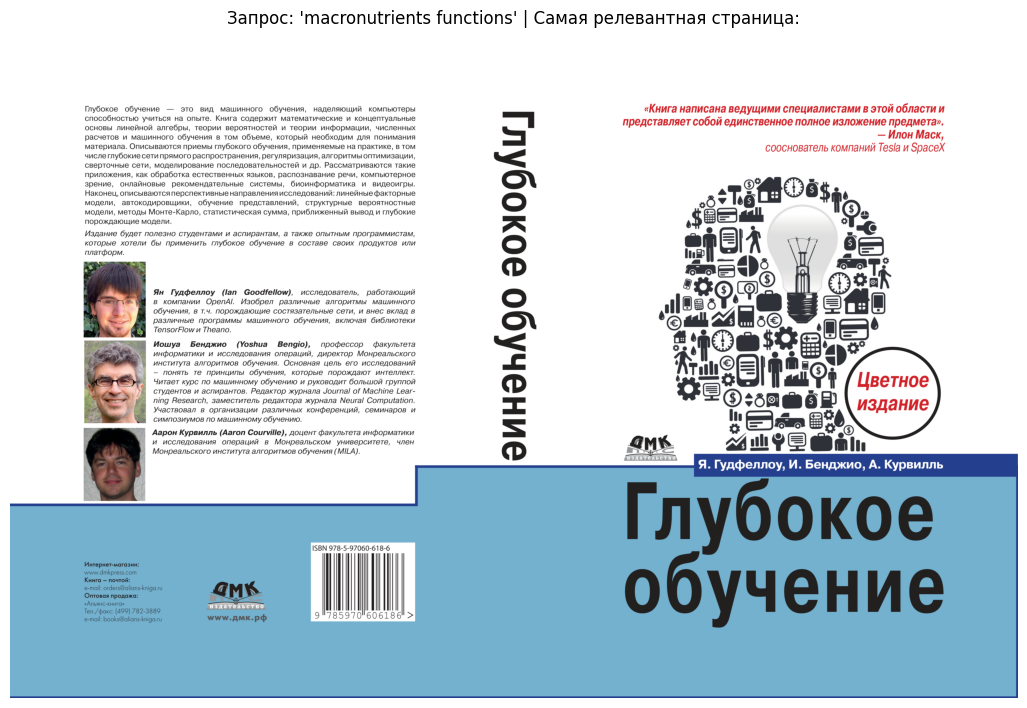

In [33]:
import fitz

# Открыть PDF и загрузить целевую страницу
pdf_path = "Глубокое обучение.pdf"
doc = fitz.open(pdf_path)
page = doc.load_page(0)

# Получить изображение страницы
img = page.get_pixmap(dpi=300)

# Опционально: сохранить изображение
# img.save("output_filename.png")
doc.close()

# Преобразовать Pixmap в массив numpy
img_array = np.frombuffer(img.samples_mv,
                          dtype=np.uint8).reshape((img.h, img.w, img.n))

# Отобразить изображение через Matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(13, 10))
plt.imshow(img_array)
plt.title(f"Запрос: '{query}' | Самая релевантная страница:")
plt.axis('off')
plt.show()

 Отлично! Теперь мы можем провести дополнительное исследование, если захотим.  

Этот рабочий процесс можно повторить для **любого запроса** в нашем учебнике.  
И он также работает с **другими типами данных**:  
- Документы поддержки клиентов,  
- Переписки по электронной почте,  
- Корпоративные планы,  
- Старые дневниковые записи.  
**Почти для всего!**  

**Рабочий процесс одинаков:**  
1. Загрузка документов → разделение на фрагменты → создание эмбеддингов.  
2. Формирование запроса → создание эмбеддинга запроса → сравнение с эмбеддингами фрагментов.  

И мы получаем релевантные материалы **вместе с их источниками**!  

Это этап **поиска** в RAG (Retrieval Augmented Generation).  

Прежде чем перейти к следующим шагам, кратко обсудим **метрики сходства**.

### Меры сходства: скалярное произведение и косинусное сходство  

Давайте обсудим методы сравнения векторов, а именно векторов эмбеддингов — числовых представлений данных с направлением и величиной в многомерном пространстве (в нашем случае размерность векторов — 768).  

Два самых распространённых метода:  
- **Скалярное произведение (Dot Product)**  
- **Косинусное сходство (Cosine Similarity)**  

Они похожи, но есть ключевое отличие: косинусное сходство включает **нормализацию**.  

| Мера сходства | Описание | Код |  
| ----- | ----- | ----- |  
| **[Скалярное произведение](https://ru.wikipedia.org/wiki/Скалярное_произведение)** | - Учитывает **направление** и **величину** векторов.<br>- Векторы, направленные в одну сторону и с большей величиной, дают положительные значения.<br>- Противоположные векторы — отрицательные. | [`torch.dot`](https://pytorch.org/docs/stable/generated/torch.dot.html), [`np.dot`](https://numpy.org/doc/stable/reference/generated/numpy.dot.html), [`sentence_transformers.util.dot_score`](https://www.sbert.net/docs/package_reference/util.html#sentence_transformers.util.dot_score) |  
| **[Косинусное сходство](https://ru.wikipedia.org/wiki/Косинусное_сходство)** | - Векторы **нормализуются** (приводятся к единичной длине с помощью [евклидовой нормы](https://ru.wikipedia.org/wiki/Норма_(математика))), чтобы сравнивать их по направлению.<br>- Совпадающие направления: значение близко к **1**.<br>- Противоположные направления: значение близко к **-1**. | [`torch.nn.functional.cosine_similarity`](https://pytorch.org/docs/stable/generated/torch.nn.functional.cosine_similarity.html), [`1 - scipy.spatial.distance.cosine`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cosine.html), [`sentence_transformers.util.cos_sim`](https://www.sbert.net/docs/package_reference/util.html#sentence_transformers.util.cos_sim) |  

**Для текста** обычно используют **косинусное сходство**, так как важно семантическое направление, а не величина.  

В нашем случае модель `all-mpnet-base-v2` (см. [Hugging Face model card](https://huggingface.co/sentence-transformers/all-mpnet-base-v2#usage-huggingface-transformers)) выдает **нормализованные эмбеддинги**, поэтому скалярное произведение и косинусное сходство дают одинаковые результаты. Однако скалярное произведение работает быстрее, так как не требует нормализации.  

**Пример:**  
```python  
# Для нормализованных векторов:  
cos_sim = dot_product  # результаты совпадают  
```  

> **Важно:** Меры сходства применимы к любым эмбеддингам — текстовым, изображений, аудио. Например, модель [CLIP](https://github.com/mlfoundations/open_clip) позволяет сравнивать эмбеддинги текста и изображений.

In [34]:
import torch

def dot_product(vector1, vector2):
    return torch.dot(vector1, vector2)

def cosine_similarity(vector1, vector2):
    dot_product = torch.dot(vector1, vector2)

    # Получить евклидову норму (L2) для каждого вектора (убирает величину, сохраняет направление)
    norm_vector1 = torch.sqrt(torch.sum(vector1**2))
    norm_vector2 = torch.sqrt(torch.sum(vector2**2))

    return dot_product / (norm_vector1 * norm_vector2)

# Примеры векторов
vector1 = torch.tensor([1, 2, 3], dtype=torch.float32)
vector2 = torch.tensor([1, 2, 3], dtype=torch.float32)
vector3 = torch.tensor([4, 5, 6], dtype=torch.float32)
vector4 = torch.tensor([-1, -2, -3], dtype=torch.float32)

# Вычисление скалярного произведения
print("Скалярное произведение vector1 и vector2:", dot_product(vector1, vector2))
print("Скалярное произведение vector1 и vector3:", dot_product(vector1, vector3))
print("Скалярное произведение vector1 и vector4:", dot_product(vector1, vector4))

# Вычисление косинусного сходства
print("Косинусное сходство vector1 и vector2:", cosine_similarity(vector1, vector2))
print("Косинусное сходство vector1 и vector3:", cosine_similarity(vector1, vector3))
print("Косинусное сходство vector1 и vector4:", cosine_similarity(vector1, vector4))

Скалярное произведение vector1 и vector2: tensor(14.)
Скалярное произведение vector1 и vector3: tensor(32.)
Скалярное произведение vector1 и vector4: tensor(-14.)
Косинусное сходство vector1 и vector2: tensor(1.0000)
Косинусное сходство vector1 и vector3: tensor(0.9746)
Косинусное сходство vector1 и vector4: tensor(-1.0000)


**Результаты сравнения:**  

- **`vector1` и `vector2`**: Оба метода дают положительные значения (14 для скалярного произведения и 1.0 для косинусного сходства).  
- **`vector1` и `vector4`**: Результаты отрицательные, так как `vector4` — противоположная версия `vector1`.  
- **`vector1` и `vector3`**:  
  - **Скалярное произведение** (32) больше, чем для `vector1` и `vector2` (14), так как учитывает величину векторов.  
  - **Косинусное сходство** (~0.974) близко к 1, но не равно ему из-за нормализации.  

**Почему косинусное сходство лучше для текста?**  
Оно фокусируется на **направлении** векторов, а не на их длине, что лучше отражает семантическую близость.  

**Особенность модели `all-mpnet-base-v2`:**  
Она возвращает **нормализованные эмбеддинги**, поэтому скалярное произведение и косинусное сходство дают одинаковые результаты. Но скалярное произведение работает быстрее.  

**Следующий шаг:**  
Оформим этапы семантического поиска в функцию для удобства.  

### Организация семантического поиска в виде функций  

Объединим все этапы семантического поиска, описанные выше, в одну или несколько функций для удобства повторного использования.  

In [35]:
def retrieve_relevant_resources(query: str,
                                embeddings: torch.tensor,
                                model: SentenceTransformer=embedding_model,
                                n_resources_to_return: int=5,
                                print_time: bool=True):
    """
    Преобразует запрос в эмбеддинг с помощью модели и возвращает топ-k оценок и индексов из эмбеддингов.
    """

    # Преобразование запроса в эмбеддинг
    query_embedding = model.encode(query,
                                   convert_to_tensor=True)

    # Расчет оценок через скалярное произведение
    start_time = timer()
    dot_scores = util.dot_score(query_embedding, embeddings)[0]
    end_time = timer()

    if print_time:
        print(f"[INFO] Время расчета для {len(embeddings)} эмбеддингов: {end_time-start_time:.5f} сек.")

    # Получение топ-k результатов
    scores, indices = torch.topk(input=dot_scores,
                                 k=n_resources_to_return)

    print(scores)

    return scores, indices


def print_top_results_and_scores(query: str,
                                 embeddings: torch.tensor,
                                 pages_and_chunks: list[dict]=pages_and_chunks,
                                 n_resources_to_return: int=5):
    """
    Получает релевантные ресурсы для запроса и выводит их в порядке убывания релевантности.
    Примечание: Требуется, чтобы pages_and_chunks был отформатирован особым образом.
    """

    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings,
                                                  n_resources_to_return=n_resources_to_return)

    print(f"Запрос: {query}\n")
    print("Результаты:")
    # Перебор оценок и индексов
    for score, index in zip(scores, indices):
        print(f"Оценка: {score:.4f}")
        # Вывод релевантного фрагмента (отсортировано по убыванию)
        print_wrapped(pages_and_chunks[index]["sentence_chunk"])
        # Вывод номера страницы для проверки
        print(f"Номер страницы: {pages_and_chunks[index]['page_number']}")
        print("\n")

Отлично! Теперь протестируем наши функции.

In [44]:
query = "градиентный спуск"

# Get just the scores and indices of top related results
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)
scores, indices

[INFO] Время расчета для 1898 эмбеддингов: 0.00011 сек.
tensor([0.7219, 0.7048, 0.6953, 0.6770, 0.6752], device='cuda:0')


(tensor([0.7219, 0.7048, 0.6953, 0.6770, 0.6752], device='cuda:0'),
 tensor([943, 630,  22, 812,  16], device='cuda:0'))

In [45]:
# Print out the texts of the top scores
print_top_results_and_scores(query=query,
                             embeddings=embeddings)

[INFO] Время расчета для 1898 эмбеддингов: 0.00009 сек.
tensor([0.7219, 0.7048, 0.6953, 0.6770, 0.6752], device='cuda:0')
Запрос: градиентный спуск

Результаты:
Оценка: 0.7219
В большинстве подобных алгоритмов поиска гиперпараметров применяется байесовская
модель регрессии для оценки как ожидаемого значения ошибки для каждого
гиперпараметра, так и неопределенности
Номер страницы: 344


Оценка: 0.7048
В той же работе высказывается предположение, что можно анали- тически доказать,
что седловая точка отталкивает, а не притягивает траекторию не- прерывного по
времени градиентного спуска, но что ситуация может оказаться иной в более
реалистичных случаях применения метода градиентного спуска.Для метода Ньютона
седловые точки представляют очевидную проблему.Идея алгоритма градиентного
спуска  – «спуск с  горы», а  не явный поиск критических точек.С другой стороны,
метод Ньютона специально предназначен для поиска то- чек с нулевым
градиентом.Без надлежащей модификации он вполне может найти сед

### Расширения семантического/векторного поиска  

Мы рассмотрели пример поиска релевантных результатов с использованием векторных эмбеддингов.  
Однако этот процесс можно дополнить **традиционным поиском по ключевым словам**.  
Многие современные системы используют гибридный подход: **ключевые слова + векторный поиск**.  

**Проблема масштабирования:**  
- Для небольших данных (как в нашем примере) подходит **полный перебор** (сравнение запроса со всеми эмбеддингами).  
- Для больших наборов (миллионы/миллиарды векторов) требуется **индексирование**.  

**Индексы** упорядочивают эмбеддинги, сужая область поиска.  
*Аналогия:* Чтобы найти слово "утка" в словаре, вы открываете раздел на букву «У», а не просматриваете каждую страницу.  

**Библиотеки для индексирования:**  
- **[Faiss](https://github.com/facebookresearch/faiss)** (Facebook AI Similarity Search):  
  - Открытая библиотека для эффективного поиска в больших векторных пространствах.  
  - Реализует алгоритмы вроде **[HNSW](https://arxiv.org/abs/1603.09320)** (Иерархические Навигируемые Малые Миры), которые балансируют скорость и точность.  
- **[Annoy](https://github.com/spotify/annoy)** (Spotify): Ещё один популярный инструмент для приближённого поиска соседей.  

**Зачем это нужно?**  
Индексы позволяют искать в **огромных наборах данных** без потери производительности.  
Подробнее: [Поиск ближайшего соседа](https://ru.wikipedia.org/wiki/Поиск_ближайшего_соседа).  

### Выбор LLM для локальной генерации  

Наш этап поиска готов, перейдем к генерации ответов.  
Для этого используем **большую языковую модель (LLM)**, которая генерирует текст на основе входных данных.  

**Цель:**  
- Получить ответ, основанный на **контексте** из учебника и **запросе** пользователя.  
- Входные данные для LLM называются **промптом** (prompt).  

---

### **Как выбрать LLM?**  
1. **Локальный запуск или API?**  
   - **API** (GPT-4, Claude 3). Максимальная производительность, но данные отправляются на сервер.  
   - **Локальная модель**. Полный контроль, но требует вычислительных ресурсов.  

2. **Какое оборудование доступно?**  
   Чем больше модель, тем выше требования к GPU.  

**Ресурсы для выбора модели:**  
- [Hugging Face Open LLM Leaderboard](https://huggingface.co/spaces/HuggingFaceH4/open_llm_leaderboard): сравнение моделей по бенчмаркам.  
- [TheBloke](https://huggingface.co/TheBloke): квантованные (уменьшенные) версии моделей.  

---

### **Память GPU для разных размеров моделей**  
Правило: Чем больше параметров у модели, тем больше видеопамяти (VRAM) требуется.  

| Размер модели (млрд параметров) | VRAM для float32 (ГБ) | VRAM для float16 (ГБ) | VRAM для 8-бит (ГБ) | VRAM для 4-бит (ГБ) |  
|-------------------------------|-----------------------|-----------------------|----------------------|----------------------|  
| 1B                            | ~4                   | ~2                   | ~1                  | ~0.5                |  
| 7B (Llama 2 7B, Gemma 7B, Mistral 7B) | ~28       | ~14          | ~7           | ~3.5         |  
| 10B                           | ~40                  | ~20                  | ~10                 | ~5                  |  
| 70B (Llama 2 70B)             | ~280                 | ~140                 | ~70                 | ~35                 |  
| 100B                          | ~400                 | ~200                 | ~100                | ~50                 |  
| 175B                          | ~700                 | ~350                 | ~175                | ~87.5               |  

> **Примечания:**  
> - **Квантование** (снижение точности) уменьшает требования к памяти, но может ухудшить качество ответов.  
> - Требуется экспериментировать, чтобы найти баланс между скоростью и качеством.  

---

### **Рекомендации**  
- Для локального запуска на GPU:  
  - **7B-модели** (например, Gemma3, Qwen3) — оптимальный выбор для большинства задач.  
  - **3B-модели** подойдут для слабого железа.  
- Для API: Используйте GPT-4 или Claude 3, если конфиденциальность данных не критична.  

### Тестирование модели Gemma от Google  

Попробуем недавно выпущенную модель **Gemma** ([официальный блог](https://huggingface.co/blog/gemma)), а именно версию `gemma-7b-it` (7 млрд параметров, обученная следовать инструкциям).  

**Инструктивное обучение (Instruction Tuning)** — это дообучение базовой модели для выполнения задач по инструкциям (как ChatGPT или Gemini).  

---

### **Требования к памяти для Gemma**  

| Модель             | Точность   | Память (байты)    | Память (МБ)   | Память (ГБ)   | Рекомендуемая память (ГБ) | ID на Hugging Face |  
|-------------------|------------|-------------------|---------------|---------------|--------------------------|--------------------|  
| [Gemma 2B](https://huggingface.co/google/gemma-2b-it) | 4-бит      | 2,106,749,952     | 2009.15       | 1.96          | ~5.0                    | `gemma-2b` / `gemma-2b-it` |  
| Gemma 2B          | Float16    | 5,079,453,696     | 4844.14       | 4.73          | ~8.0                    | Тот же             |  
| [Gemma 7B](https://huggingface.co/google/gemma-7b-it) | 4-бит      | 5,515,859,968     | 5260.33       | 5.14          | ~8.0                    | `gemma-7b` / `gemma-7b-it` |  
| Gemma 7B          | Float16    | 17,142,470,656    | 16348.33      | 15.97         | ~19                     | Тот же             |  

> **Примечания:**  
> - `gemma-7b-it` — инструктивно обученная версия базовой модели `gemma-7b`.  
> - Квантованные версии (GGUF и другие) доступны через [TheBloke](https://huggingface.co/TheBloke).  
> - Выбор модели зависит от задач и экспериментов.  

In [38]:
use_quantization_config = False
model_id = "Qwen/Qwen2.5-3B-Instruct"

print(f"use_quantization_config set to: {use_quantization_config}")
print(f"model_id set to: {model_id}")

use_quantization_config set to: False
model_id set to: Qwen/Qwen2.5-3B-Instruct


### Загрузка LLM локально  

Отлично! Выбираем модель **`gemma-7b-it`** (для моей машины с RTX 4090; подстройте `model_id` и `use_quantization_config` под ваше железо).  

Инструкции по загрузке можно найти на [странице модели в Hugging Face](https://huggingface.co/google/gemma-7b-it).  

**Что понадобится:**  
1. **Конфигурация квантования** (опционально):  
   - Определяет, загружать ли модель в 4-битной точности для экономии памяти.  
   - Используется класс [`transformers.BitsAndBytesConfig`](https://huggingface.co/docs/transformers/main_classes/quantization#transformers.BitsAndBytesConfig)
   
   (требует установки [библиотеки `bitsandbytes`](https://github.com/TimDettmers/bitsandbytes) ).  
2. **ID модели**:  
   - Идентификатор модели в Hugging Face (например, `gemma-7b-it`).  
3. **Токенизатор**:  
   - Преобразует текст в токены. Создается через [`transformers.AutoTokenizer.from_pretrained()`](https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoTokenizer).  
4. **Модель LLM**:  
   - Загружается через [`transformers.AutoModelForCausalLM.from_pretrained()`](https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoModelForCausalLM) с указанием ID модели и параметров.  

**Бонус:** Проверим доступность **Flash Attention 2** через `transformers.utils.is_flash_attn_2_available()`.  
- Эта оптимизация ускоряет механизм внимания в моделях Transformer (основа многих современных LLM, включая Gemma).  
- Если доступна, используем ее. Если нет — установите по [инструкциям](https://github.com/Dao-AILab/flash-attention).  

> **Примечания:**  
> - **Flash Attention 2** работает на GPU NVIDIA с архитектурой Ampere, Ada Lovelace, Hopper (compute capability ≥8.0). Проверить можно через `torch.cuda.get_device_capability(0)`.  
> - Для доступа к Gemma необходимо [принять условия](https://huggingface.co/google/gemma-7b-it) на Hugging Face и авторизоваться через [CLI](https://huggingface.co/docs/hub/security-tokens) или `huggingface_hub.login()`.  
> - Скачивание модели может занять время: Gemma 7B весит ~16 ГБ, Gemma 2B — ~6 ГБ.  

**Приступаем к загрузке!**  

In [39]:
! pip install bitsandbytes

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [40]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.utils import is_flash_attn_2_available

# 1. Создаем конфиг квантования для загрузки облегченной модели (опционально)
# Требуется установка: !pip install bitsandbytes accelerate, см: https://github.com/TimDettmers/bitsandbytes, https://huggingface.co/docs/accelerate/
# Для моделей, требующих 4-битного квантования (используйте при нехватке видеопамяти)
from transformers import BitsAndBytesConfig
quantization_config = BitsAndBytesConfig(load_in_4bit=True,
                                         bnb_4bit_compute_dtype=torch.float16)

# Бонус: Настраиваем Flash Attention 2 для ускорения, по умолчанию "sdpa" (scaled dot product attention), если не доступно
# Flash Attention 2 требует NVIDIA GPU с compute capability 8.0+, см: https://developer.nvidia.com/cuda-gpus
# Требуется: !pip install flash-attn, см: https://github.com/Dao-AILab/flash-attention
if (is_flash_attn_2_available()) and (torch.cuda.get_device_capability(0)[0] >= 8):
  attn_implementation = "flash_attention_2"
else:
  attn_implementation = "sdpa"
print(f"[INFO] Используемая реализация внимания: {attn_implementation}")

# 2. Выбираем модель (зависит от доступной видеопамяти)
print(f"[INFO] Используемая model_id: {model_id}")

# 3. Инициализируем токенизатор (преобразует текст в числа)
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=model_id)

# 4. Инициализируем модель
llm_model = AutoModelForCausalLM.from_pretrained(pretrained_model_name_or_path=model_id,
                                                 torch_dtype=torch.float16, # используемый тип данных
                                                 quantization_config=quantization_config if use_quantization_config else None,
                                                 low_cpu_mem_usage=False, # использовать всю память
                                                 attn_implementation=attn_implementation) # версия механизма внимания

if not use_quantization_config: # при квантовании устройство выбирается автоматически
    llm_model.to("cuda")

[INFO] Используемая реализация внимания: flash_attention_2
[INFO] Используемая model_id: Qwen/Qwen2.5-3B-Instruct


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

У нас есть LLM модель!  

Давайте проверим ее в работе.

In [41]:
llm_model

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-35): 36 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=True)
          (k_proj): Linear(in_features=2048, out_features=256, bias=True)
          (v_proj): Linear(in_features=2048, out_features=256, bias=True)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (up_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (down_proj): Linear(in_features=11008, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((2048,), eps=1e-06)
    (ro

### Генерация текста с помощью нашей LLM-модели

Мы можем генерировать текст с помощью нашего экземпляра LLM-модели, используя метод [`generate()`](https://huggingface.co/docs/transformers/main_classes/text_generation#transformers.GenerationConfig) (этот метод имеет множество параметров настройки) и передавая ему токенизированный входной текст.

Токенизированный вход получается путем передачи строки текста в наш `tokenizer`.

Важно отметить, что следует использовать токенизатор, который был спарен с моделью. В противном случае, если вы попытаетесь использовать другой токенизатор и передать эти входные данные в модель, скорее всего, вы получите ошибки или странные результаты.

Для некоторых LLM-моделей существует определенный шаблон, который следует использовать для получения идеальных результатов. Например, модель `gemma-7b-it` была обучена в диалоговом формате (инструктивное обучение). В этом случае наш `tokenizer` имеет метод [`apply_chat_template()`](https://huggingface.co/docs/transformers/main/en/internal/tokenization_utils#transformers.PreTrainedTokenizerBase.apply_chat_template), который может подготовить наш входной текст в правильном формате для модели.

Давайте попробуем это на практике.

> **Примечание:**
Следующая демонстрация была адаптирована из карточки модели Hugging Face для [Gemma 7B](https://huggingface.co/google/gemma-7b-it). Многие подобные примеры использования доступны в карточках аналогичных моделей.

In [46]:
input_text = "Какие основные методы регуляризации используются в глубоком обучении и зачем они нужны?"
print(f"Input text:\n{input_text}")

# Create prompt template for instruction-tuned model
dialogue_template = [
    {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
    {"role": "user", "content": input_text}
]

# Apply the chat template
prompt = tokenizer.apply_chat_template(conversation=dialogue_template,
                                       tokenize=False, # keep as raw text (not tokenized)
                                       add_generation_prompt=True)
print(f"\nPrompt (formatted):\n{prompt}")

Input text:
Какие основные методы регуляризации используются в глубоком обучении и зачем они нужны?

Prompt (formatted):
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Какие основные методы регуляризации используются в глубоком обучении и зачем они нужны?<|im_end|>
<|im_start|>assistant



Обратите внимание на структуру входного текста — это пример пошаговой настройки инструкций, через которую прошла наша модель.

Следующий шаг: токенизировать этот отформатированный текст и передать его методу `generate()` модели.  

Убедимся, что токенизированные данные находятся на том же устройстве, что и модель (GPU), используя `to("cuda")`.  

Давайте сгенерируем текст!  

Замерим время выполнения с помощью магической команды `%%time`.  

In [47]:
%%time

# Токенизировать входной текст (преобразовать в числа) и отправить на GPU
input_ids = tokenizer(prompt, return_tensors="pt").to("cuda")
print(f"Входные данные модели (токенизированные):\n{input_ids}\n")

# Сгенерировать выходные данные на основе токенизированных входных данных
# См. документацию по generate: https://huggingface.co/docs/transformers/v4.38.2/en/main_classes/text_generation#transformers.GenerationConfig
outputs = llm_model.generate(**input_ids,
                             max_new_tokens=256) # определить максимальное количество новых токенов для создания
print(f"Выходные данные модели (токены):\n{outputs[0]}\n")

Входные данные модели (токенизированные):
{'input_ids': tensor([[151644,   8948,    198,   2610,    525,   1207,  16948,     11,   3465,
            553,  54364,  14817,     13,   1446,    525,    264,  10950,  17847,
             13, 151645,    198, 151644,    872,    198, 140814,  49206, 126068,
          42965,  55629,   4552, 142405,   3780,  13695,  30103,   8959,  53586,
         139193,  20562,   5805, 132853,  63469,  14746,  12228, 143180,  83098,
           7587,  43846, 127090, 128729, 141217,     30, 151645,    198, 151644,
          77091,    198]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')}

Выходные данные модели (токены):
tensor([151644,   8948,    198,   2610,    525,   1207,  16948,     11,   3465,
           553,  54364,  14817,     13,   1446,    525,    264,  1

Ура! Мы только что сгенерировали текст на локальном GPU!  

Но не спешите радоваться...  

Наша LLM принимает токены на вход и возвращает токены на выходе.  

Преобразовать выходные токены в текст можно с помощью [`tokenizer.decode()`](https://huggingface.co/docs/transformers/main_classes/tokenizer#transformers.PreTrainedTokenizer.decode).  

In [48]:
# Decode the output tokens to text
outputs_decoded = tokenizer.decode(outputs[0])
print(f"Model output (decoded):\n{outputs_decoded}\n")

Model output (decoded):
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Какие основные методы регуляризации используются в глубоком обучении и зачем они нужны?<|im_end|>
<|im_start|>assistant
Основные методы регуляризации в глубоком обучении направлены на предотвращение переобучения модели и улучшение ее генерации прогнозов для новых данных. Вот некоторые из самых распространенных методов регуляризации:

1. **Регуляризация L1 и L2**:
   - **L1 (Абсолютная регуляризация)**: Включает в себя сумму модулей весов модели. Это может привести к тому, что некоторые веса могут стать равными нулю, что делает модель более простой.
   - **L2 (Квадратичная регуляризация)**: Включает в себя сумму квадратов весов. Этот метод также способствует уменьшению значений весов, но в отличие от L1, он не приводит к тому, что веса становятся точно нулевыми.

2. **Декомпозиция весов**:
   - В некоторых случаях, веса модели разделяются на два или 

Вау! Похоже, это неплохой ответ.  

Но замечаете, что вывод включает исходный промпт?  

Давайте немного отформатируем вывод, чтобы убрать промпт из текста.  

> **Примечание:** `<bos>` (beginning of sentence) и `<eos>` (end of sentence) — специальные токены, обозначающие начало и конец предложения.  

In [49]:
print(f"Input text: {input_text}\n")
print(f"Output text:\n{outputs_decoded.replace(prompt, '').replace('<bos>', '').replace('<eos>', '')}")

Input text: Какие основные методы регуляризации используются в глубоком обучении и зачем они нужны?

Output text:
Основные методы регуляризации в глубоком обучении направлены на предотвращение переобучения модели и улучшение ее генерации прогнозов для новых данных. Вот некоторые из самых распространенных методов регуляризации:

1. **Регуляризация L1 и L2**:
   - **L1 (Абсолютная регуляризация)**: Включает в себя сумму модулей весов модели. Это может привести к тому, что некоторые веса могут стать равными нулю, что делает модель более простой.
   - **L2 (Квадратичная регуляризация)**: Включает в себя сумму квадратов весов. Этот метод также способствует уменьшению значений весов, но в отличие от L1, он не приводит к тому, что веса становятся точно нулевыми.

2. **Декомпозиция весов**:
   - В некоторых случаях, веса модели разделяются на два или более блока, каждый из которых подвергается от


Как это круто!  

Мы только что официально сгенерировали текст с помощью LLM-модели, работающей локально.  

Итак, мы рассмотрели этапы **R (поиск)** и **G (генерация)** в RAG.  

Как насчет последнего шага?  

**Расширение (Augmentation)**.  

Для начала составим список запросов, которые мы можем протестировать в нашем пайплайне.  

In [50]:
# Вопросы по глубокому обучению, сгенерированные с помощью GPT4
gpt4_questions = [
    "Какие основные методы регуляризации используются в глубоком обучении и зачем они нужны?",
    "Чем сверточные нейронные сети отличаются от полносвязных сетей?",
    "Опишите процесс обратного распространения ошибки в нейронной сети.",
    "Какую роль играет функция активации в глубоком обучении? Назовите основные виды.",
    "Объясните концепцию переобучения и методы борьбы с ним."
]

# Вопросы, составленные вручную
manual_questions = [
    "Как работает метод стохастического градиентного спуска?",
    "Что такое автокодировщик?",
    "Как работает механизм внимания в нейронных сетях?",
    "Какие существуют методы оптимизации для обучения нейронных сетей?",
    "порождающие состязательные сети"
]

query_list = gpt4_questions + manual_questions

А теперь проверим, работает ли функция `retrieve_relevant_resources()` с нашим списком запросов.  

In [51]:
import random
query = random.choice(query_list)

print(f"Query: {query}")

# Get just the scores and indices of top related results
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)
scores, indices

Query: Что такое автокодировщик?
[INFO] Время расчета для 1898 эмбеддингов: 0.00031 сек.
tensor([0.6419, 0.6361, 0.6265, 0.6214, 0.6107], device='cuda:0')


(tensor([0.6419, 0.6361, 0.6265, 0.6214, 0.6107], device='cuda:0'),
 tensor([  34,   33, 1249,   44,   12], device='cuda:0'))

Прекрасно!

### Расширение промпта контекстными элементами  

**Цель аугментации** — включить результаты семантического поиска в промпт для LLM.  
По сути мы берем базовый запрос и обогащаем его релевантным контекстом.  

**Функция `prompt_formatter`:**  
1. Принимает:  
   - `query`: пользовательский запрос;  
   - `context_items`: список контекстных фрагментов (выбранных из `pages_and_chunks` по индексам).
2. Форматирует запрос с текстом из контекста.  
3. Применяет шаблон диалога для модели (например, через `apply_chat_template()`).  

> **Примечание:** Процесс модификации промпта для LLM называется **промпт-инжинирингом**. Это активно развивающаяся область.  
> **Рекомендуемые ресурсы:**  
> - [Руководство по промпт-инжинирингу](https://www.promptingguide.ai/ru)  
> - [Гайд от Brex](https://github.com/brexhq/prompt-engineering)  
> - Исследование: [Дизайн промптов](https://arxiv.org/abs/2401.14423)  

In [52]:
def base_prompt_formatter(query: str) -> str:
    """
    Обычная генерация
    """

    # Создает шаблон промпта для инструктивно настроенной модели
    dialogue_template = [
        {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
        {"role": "user", "content": query}
    ]

    # Применяет шаблон чата
    prompt = tokenizer.apply_chat_template(conversation=dialogue_template,
                                           tokenize=False,
                                           add_generation_prompt=True)
    return prompt

In [53]:
def rag_prompt_formatter(query: str,
                         context_items: list[dict]) -> str:
    """
    Дополняет запрос текстовым контекстом из context_items.
    """
    # Объединяет элементы контекста в маркированный список
    context = "- " + "\n- ".join([item["sentence_chunk"] for item in context_items])

    # Создает базовый промпт с примерами ответов
    # Примечание: это можно легко настраивать. Здесь используются 3 примера желаемого стиля ответов.
    # Можно также хранить это в txt-файле и импортировать
    base_prompt = """Context relevant information:\n{context}\nUser query: {query}\nAnswer: """

    # Вставляет контекст и запрос в базовый промпт
    base_prompt = base_prompt.format(context=context, query=query)

    # Создает шаблон промпта для инструктивно настроенной модели
    dialogue_template = [
        {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant. Your answer should be based on given context relevant information. Make sure your answers are as explanatory as possible."},
        {"role": "user", "content": base_prompt}
    ]

    # Применяет шаблон чата
    prompt = tokenizer.apply_chat_template(conversation=dialogue_template,
                                          tokenize=False,
                                          add_generation_prompt=True)
    return prompt

Выглядит отлично! Давайте протестируем нашу функцию.  

In [54]:
# Выбрать случайный запрос из списка
# query = random.choice(query_list)
query = "Расскажи мне про большой теннис"
print(f"Запрос: {query}")

# Получить релевантные ресурсы
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)

# Создать список контекстных элементов из найденных индексов
context_items = [pages_and_chunks[i] for i in indices]

# Форматировать промпт с контекстными элементами
rag_prompt = rag_prompt_formatter(query=query,
                                  context_items=context_items)

base_prompt = base_prompt_formatter(query=query)

print('RAG PROMPT: \n', rag_prompt)
print('BASE PROMPT: \n', base_prompt)

Запрос: Расскажи мне про большой теннис
[INFO] Время расчета для 1898 эмбеддингов: 0.00012 сек.
tensor([0.6361, 0.6137, 0.6092, 0.6067, 0.5975], device='cuda:0')
RAG PROMPT: 
 <|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant. Your answer should be based on given context relevant information. Make sure your answers are as explanatory as possible.<|im_end|>
<|im_start|>user
Context relevant information:
- Путь через V-структуру блокиру- ется только тогда, когда ни один из потомков общей дочерней вершины не является наблю­даемой величиной
- Чем больше сеть, тем выше ее точность на более сложных задачах.Эта тенденция прослеживается на протяжении десятилетий.Если темпы масштабирования не ускорятся в результате внедрения новых технологий, то искусственная нейронная сеть сравняется с человеческим мозгом по числу нейронов
- Справа) Соседние примеры для предковой выборки из порождающей состязательной сети.Поскольку предковая выборка порож- дает примеры неза

Какой отличный промпт!  

Мы можем токенизировать его и сразу передать в LLM.  

In [55]:
%%time

input_ids = tokenizer(rag_prompt, return_tensors="pt").to("cuda")

# Generate an output of tokens
outputs = llm_model.generate(**input_ids,
                             temperature=0.7, # lower temperature = more deterministic outputs, higher temperature = more creative outputs
                             do_sample=True, # whether or not to use sampling, see https://huyenchip.com/2024/01/16/sampling.html for more
                             max_new_tokens=256) # how many new tokens to generate from prompt

# Turn the output tokens into text
output_text = tokenizer.decode(outputs[0])

print(f"Query: {query}")
print(f"RAG answer:\n{output_text.replace(prompt, '')}")

Query: Расскажи мне про большой теннис
RAG answer:
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant. Your answer should be based on given context relevant information. Make sure your answers are as explanatory as possible.<|im_end|>
<|im_start|>user
Context relevant information:
- Путь через V-структуру блокиру- ется только тогда, когда ни один из потомков общей дочерней вершины не является наблю­даемой величиной
- Чем больше сеть, тем выше ее точность на более сложных задачах.Эта тенденция прослеживается на протяжении десятилетий.Если темпы масштабирования не ускорятся в результате внедрения новых технологий, то искусственная нейронная сеть сравняется с человеческим мозгом по числу нейронов
- Справа) Соседние примеры для предковой выборки из порождающей состязательной сети.Поскольку предковая выборка порож- дает примеры независимо, то проблемы перемешивания нет
- Например, если при- меняется неявное дополнение нулями, то детекторные блоки на грани

In [56]:
%%time

input_ids = tokenizer(base_prompt, return_tensors="pt").to("cuda")

# Generate an output of tokens
outputs = llm_model.generate(**input_ids,
                             temperature=0.7, # lower temperature = more deterministic outputs, higher temperature = more creative outputs
                             do_sample=True, # whether or not to use sampling, see https://huyenchip.com/2024/01/16/sampling.html for more
                             max_new_tokens=256) # how many new tokens to generate from prompt

# Turn the output tokens into text
output_text = tokenizer.decode(outputs[0])

print(f"Query: {query}")
print(f"RAG answer:\n{output_text.replace(prompt, '')}")

Query: Расскажи мне про большой теннис
RAG answer:
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Расскажи мне про большой теннис<|im_end|>
<|im_start|>assistant
Конечно! Большой теннис, также известный как теннис на корте, является популярным видом спорта с глубокими историческими корнями и сложной техникой игры.

### История
1. **Начало**: Теннис был изобретен в Англии в XVIII веке. Первые игры были очень просты и не имели множества правил.
2. **Развитие**: В XIX веке правила игры стали более четкими, а форма игры — более формальной. В 1874 году было принято решение о том, что игра должна проводиться на корте с сеткой.
3. **Популярность**: В XX веке теннис стал одним из самых популярных видов спорта во всем мире. В 1968 году была создана Международная федерация тенниса (ITF), которая регулирует правила и организует турниры по всему миру.

### Составляющие игры
1. **Игроки**: В большом теннисе игра
CPU times: user 22.

Урааааа!!!  

Наш RAG-пайплайн готов!  
Мы только что выполнили **Поиск**, **Расширение** и **Генерацию**!  

**Давайте оформим этап генерации в функцию** для удобства:  
- Добавим форматирование вывода.
- Включим опцию возврата контекстных элементов.   

In [57]:
def ask(query,
        temperature=0.7,
        max_new_tokens=512,
        format_answer_text=True,
        return_answer_only=True):
    """
    Принимает запрос, находит релевантные ресурсы/контекст и генерирует ответ на основе найденных ресурсов.
    """

    # Получает оценки и индексы топовых результатов
    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings)

    # Создает список контекстных элементов
    context_items = [pages_and_chunks[i] for i in indices]

    # Добавляет оценку к элементу контекста
    for i, item in enumerate(context_items):
        item["score"] = scores[i].cpu()  # возвращает оценку обратно на CPU

    # Форматирует промпт с контекстными элементами
    prompt = rag_prompt_formatter(query=query,
                                  context_items=context_items)

    # Токенизирует промпт (преобразует в числа для модели)
    input_ids = tokenizer(prompt, return_tensors="pt").to("cuda")

    # Генерирует выходные токены на основе входных данных
    outputs = llm_model.generate(**input_ids,
                                 temperature=temperature,  # параметр температуры для генерации
                                 do_sample=True,  # включает стохастическую выборку
                                 max_new_tokens=max_new_tokens)  # ограничение новых токенов

    # Преобразует выходные токены в текст
    output_text = tokenizer.decode(outputs[0])

    if format_answer_text:
        # Удаляет служебные токены и лишние сообщения
        output_text = output_text.replace(prompt, "")\
                                 .replace("<bos>", "")\
                                 .replace("<eos>", "")\
                                 .replace("Sure, here is the answer to the user query:\n\n", "")

    # Возвращает только ответ без контекста
    if return_answer_only:
        return output_text

    # Возвращает ответ и контекстные элементы
    return output_text, context_items

Какая отличная функция!  
Рабочий процесс, возможно, можно немного доработать, но в целом всё должно работать!  
Давайте протестируем!  

In [58]:
query = random.choice(query_list)
print(f"Query: {query}")

# Answer query with context and return context
answer, context_items = ask(query=query,
                            temperature=0.7,
                            max_new_tokens=512,
                            return_answer_only=False)

print(f"Answer:\n")
print_wrapped(answer)

print(f"\nContext items:")
for context_item in context_items:
    print(context_item['sentence_chunk'])

Query: Как работает метод стохастического градиентного спуска?
[INFO] Время расчета для 1898 эмбеддингов: 0.00020 сек.
tensor([0.7388, 0.7164, 0.7036, 0.7032, 0.6889], device='cuda:0')
Answer:

Метод стохастического градиентного спуска (SGD - Stochastic Gradient Descent) -
это эффективный метод оптимизации функций, особенно подходящий для обучения
глубоких нейронных сетей.   Основная идея метода заключается в том, чтобы вместо
использования градиента для всей обучающей выборки (что требует большого объема
вычислений), использовать только один или несколько случайных элементов из этой
выборки. Это делает процесс обучения более быстрым, поскольку потребуется меньше
вычислений.  Ключевые особенности метода SGD:  1. **Ускорение обучения**:
Потребляет меньше вычислительных ресурсов и время на каждой итерации по
сравнению с методом градиентного спуска с большим шагом (BGD), который
использует градиент всего набора данных.  2. **Непрерывность процесса**: Дает
возможность продолжать обучение д

# Построение RAG системы с помощью LangChain

In [59]:
! pip uninstall langchain langchain-core langgraph-prebuilt langgraph -y
! pip install -q "langchain-core<1.0"
! pip install -q "langchain_huggingface<1.0"
! pip install -q "langchain-community<0.4"
! pip install -q "langchain<1.0"
! pip install -q faiss-cpu

Found existing installation: langchain 0.3.28
Uninstalling langchain-0.3.28:
  Successfully uninstalled langchain-0.3.28
Found existing installation: langchain-core 0.3.83
Uninstalling langchain-core-0.3.83:
  Successfully uninstalled langchain-core-0.3.83
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-community 0.3.27 requires langchain<1.0.0,>=0.3.26, which is not installed.
ragas 0.2.15 requires langchain, which is not installed.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cloudru-jupyter-ai-magics 2.32.1 requires parso>=0.8.4, but you have parso 0.7.1 which is incompatible.


In [60]:
import os
import getpass

os.environ['GIGACHAT_API_KEY'] = getpass.getpass(prompt='GIGACHAT_API_KEY: ', stream=None)

GIGACHAT_API_KEY:  ········


In [61]:
from langchain.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [62]:
! pip install -q gigachat langchain_gigachat

In [63]:
from langchain_gigachat.embeddings import GigaChatEmbeddings

giga_api_key = os.getenv("GIGACHAT_API_KEY", "")

In [64]:
# Загрузка PDF
pdf_path = "Глубокое обучение.pdf"
loader = PyMuPDFLoader(pdf_path)
documents = loader.load()

# Разделим документ на части
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
)
texts = text_splitter.split_documents(documents)

# Создание эмбеддинг модели
embeddings = GigaChatEmbeddings(credentials=giga_api_key, scope='GIGACHAT_API_B2B', verify_ssl_certs=False)

# Создание векторного хранилища
db = FAISS.from_documents(texts, embeddings)

# Сохранение индекса для последующего использования
db.save_local("faiss_index")

In [65]:
# Если нужно загрузить сохраненный индекс
# db = FAISS.load_local("faiss_index", embeddings)

# Выполнение поиска
query = "методы регуляризации в глубоком обучении"  # Замените на ваш запрос
results = db.similarity_search(query, k=3)

# Вывод результатов
for i, result in enumerate(results):
    print(f"Результат {i+1}:")
    print(result.page_content)
    print("\n")

Результат 1:
Глава 7
Регуляризация 
в глубоком обучении
Центральная проблема машинного обучения – как создать алгоритм, который будет 
хорошо работать не только на обучающих, но и на новых данных. Многие используе­
мые стратегии специально предназначены для уменьшения ошибки тестирования, 
быть может, за счет увеличения ошибки обучения. Эти стратегии известны под об-
щим названием «регуляризация». В распоряжении специалиста по глубокому обуче-
нию много вариантов регуляризации. На самом деле разработка все более эффектив-
ных стратегий регуляризации – одно из основных направлений исследований в этой 
области.
В главе 5 были введены понятия обобщения, недообучения, переобучения, сме-
щения, дисперсии и регуляризации. Если вы пока незнакомы с ними, ознакомьтесь 
с главой 5, прежде чем продолжать чтение.
В этой главе мы опишем регуляризацию подробно, уделив особое внимание стра-
тегиям регуляризации глубоких моделей или моделей, которые используются в каче-
стве их строительных блоков.




In [66]:
from langchain_huggingface import HuggingFacePipeline
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
import torch

# Загрузка модели и токенизатора
model_name = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

# Создание пайплайна
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=200,
    temperature=0.7,
    top_p=0.9,
    do_sample=True,
    return_full_text=False
)

# Интеграция с LangChain
llm = HuggingFacePipeline(pipeline=pipe)

Device set to use cuda:0


In [67]:
from langchain_gigachat.chat_models import GigaChat

giga = GigaChat(
    credentials=giga_api_key,
    verify_ssl_certs=False,
    scope='GIGACHAT_API_B2B',
    model='GigaChat-2-Max'
)

In [68]:
from langchain.prompts import PromptTemplate
from langchain.chains import RetrievalQA


# Шаблон промпта
template = """Вы — помощник, который отвечает на вопросы на основе предоставленных документов. Используйте только информацию из контекста. Если ответа нет в контексте, скажите: "Информация отсутствует в предоставленных документах."

Контекст: {context}

Вопрос: {question}

Ответ: """
prompt = PromptTemplate(template=template, input_variables=["context", "question"])

# Настройка цепочки RAG
qa_chain = RetrievalQA.from_chain_type(
    llm=giga,
    chain_type="stuff",
    retriever=db.as_retriever(search_kwargs={"k": 3}),
    return_source_documents=True,
    chain_type_kwargs={"prompt": prompt}
)

In [69]:
# Запрос
query = "методы регуляризации в глубоком обучении"

# Вызов цепочки
result = qa_chain({"query": query})

# Вывод ответа и источников
print("Ответ:", result["result"])
print("\nИсточники:")
for i, doc in enumerate(result["source_documents"]):
    print(f"Документ {i+1}:")
    print(doc.page_content[:200], "...")
    print("\n")

/tmp/ipykernel_1919180/1632320974.py:5: LangChainDeprecationWarning: The method `Chain.__call__` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  result = qa_chain({"query": query})


Ответ: Методы регуляризации в глубоком обучении включают следующие основные направления:

1. **Ограничение значений параметров**: добавление жестких ограничений на параметры модели (например, ограничение диапазона весов).
   
2. **Штрафование целевой функции**: включение дополнительных членов в целевую функцию, действующих как штраф за большие значения параметров (например, L1-регуляризация и L2-регуляризация).

3. **Использование ранних остановок**: прекращение процесса обучения до полного переобучения на тренировочных данных путем оценки производительности на отдельной проверочной выборке.

4. **Дропаут (dropout)**: временный отказ от части нейронов во время тренировки для предотвращения зависимости между ними и снижения переобучения.

5. **Нормализация входных данных** и использование методов нормализации внутри сети (batch normalization, layer normalization и др.), позволяющих стабилизировать обучение и повысить устойчивость модели.

6. **Снижение сложности архитектуры**: уменьшени

**Локальный RAG-пайплайн завершен!**  

Теперь у нас есть полноценная система для:  
1. **Поиска (Retrieve)** релевантных данных,  
2. **Расширения (Augment)** запроса контекстом,  
3. **Генерации (Generate)** ответов на основе источника.  

**Проверка результатов:**  
- Сейчас мы можем анализировать ответы вручную, сравнивая их с учебником.  

**Для продакшн-решения рекомендуется:**  
- Добавить **систему оценки качества** работы пайплайна.  
- Например, использовать **дополнительную LLM** для оценки сгенерированных ответов (например, по шкале от 1 до 5).    

## Расширения функционала  

* **Улучшение извлечения текста** — использовать инструменты вроде [Marker](https://github.com/VikParuchuri/marker).  
* **Расширенное извлечение текста из PDF** — [гайд по методам](https://towardsdatascience.com/extracting-text-from-pdf-files-with-python-a-comprehensive-guide-9fc4003d517).  
* **Промпт-инжиниринг** — дополнительные техники:  
  - [promptingguide.ai](https://www.promptingguide.ai/)  
  - [Гайд от Brex](https://github.com/brexhq/prompt-engineering).  
* **Обработка запросов без контекста** — что делать, если в учебнике нет информации по запросу?  
* **Тестирование других моделей эмбеддингов** — например, [mixedbread-ai/mxbai-embed-large-v1](https://huggingface.co/mixedbread-ai/mxbai-embed-large-v1).  
* **Другие LLM** — попробуйте [Mistral-Instruct](https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.2).  
* **Эксперименты с промптами** — разные форматы запросов.  
* **Работа с изображениями** — расширение пайплайна для анализа графиков и картинок.  
* **Оценка ответов** — использовать другую LLM (например, GPT-4) для автоматической проверки качества.  
* **Векторные базы данных** — переход на FAISS/Pinecone для больших данных (100 000+ фрагментов).  
* **Использование фреймворков** — [LangChain](https://www.langchain.com/), [LlamaIndex](https://gpt-index.readthedocs.io/) для автоматизации шагов.  
* **Оптимизация скорости:**  
  - [Рекомендации Hugging Face для GPU](https://huggingface.co/docs/transformers/perf_infer_gpu_one)  
  - [Optimum NVIDIA](https://github.com/huggingface/optimum-nvidia)  
  - [NVIDIA TensorRT-LLM](https://github.com/NVIDIA/TensorRT-LLM)  
  - [GPT-Fast](https://github.com/pytorch-labs/gpt-fast)  
  - [Flash Attention 2](https://github.com/Dao-AILab/flash-attention) (требуется GPU Ampere или новее).  
* **Потоковый вывод текста** — показ токенов по мере генерации.  
* **Создание приложения** — например, через [Gradio-чат-боты](https://www.gradio.app/guides/creating-a-chatbot-fast).  